# Strava Fitness Analytics: Understanding User Activity, Sleep, and Body Metrics

## Problem Statement

Fitness tracking apps generate enormous amounts of behavioral data — but that
data is only useful if it's turned into clear, actionable insight. This project
analyzes daily user activity, sleep, and weight data to understand how these
three behaviors relate to one another, with the goal of producing concrete,
number-backed recommendations for a fitness app's product and marketing strategy.

**Business Objective:** Analyze how users' daily activity, sleep, and body
metrics relate to each other, and produce actionable recommendations for a
fitness app based on real usage patterns — not assumptions about how users
"should" behave.

## Data Source

This analysis uses the public FitBit Fitness Tracker dataset (33 users, daily
records from April–May 2016), used here as a proxy for Strava-style user
tracking behavior. Three core datasets are used:

- **dailyActivity_merged.csv** — 940 rows, 33 users: steps, distance, active
  minutes by intensity, and calories burned per day.
- **sleepDay_merged.csv** — 413 rows (410 after removing duplicates), 24 users:
  sleep records per night.
- **weightLogInfo_merged.csv** — 67 rows, 8 users: weight and BMI logs.

Minute- and hour-level files were intentionally excluded — this analysis
works at daily grain only, matching the scope needed to answer the business
questions above without unnecessary complexity.

## Methodology

This project follows the analytical approach used in the well-known Bellabeat
case study (clean → explore → merge → analyze → recommend), applying that
same structure to this dataset. This is **not** a Bellabeat project — the
FitBit dataset and Strava framing are used independently, with only the
general analytical methodology carried over.

## A Note on Sample Size

Not all three datasets have equal coverage. Activity data covers all 33 users,
but only 24 logged sleep, and only 8 logged weight. This gap matters: any
finding involving sleep should be read as describing roughly three-quarters
of the user base, and any finding involving weight or BMI should be read as
describing 8 specific individuals, not a generalizable population. This
caveat is repeated throughout the analysis wherever it's relevant, rather
than stated once and forgotten.

In [27]:
import pandas as pd

# Load the 3 core datasets
daily = pd.read_csv('dailyActivity_merged.csv')
sleep = pd.read_csv('sleepDay_merged.csv')
weight = pd.read_csv('weightLogInfo_merged.csv')

def audit(df, name, date_col):
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"Shape: {df.shape}")
    print(f"Unique users (Id): {df['Id'].nunique()}")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print(f"Date column '{date_col}' sample values: {df[date_col].unique()[:3]}")
    print(f"\nNull counts per column:\n{df.isnull().sum()}")
    print(f"\nDtypes:\n{df.dtypes}")

audit(daily, "dailyActivity_merged", "ActivityDate")
audit(sleep, "sleepDay_merged", "SleepDay")
audit(weight, "weightLogInfo_merged", "Date")

# Zero-activity check
print(f"\nRows where TotalSteps == 0: {(daily['TotalSteps']==0).sum()} out of {len(daily)}")

# Fat column specifically
print(f"\nweightLogInfo Fat column — non-null: {weight['Fat'].notna().sum()} out of {len(weight)}")
print(f"IsManualReport value counts:\n{weight['IsManualReport'].value_counts()}")


dailyActivity_merged
Shape: (940, 15)
Unique users (Id): 33
Duplicate rows: 0
Date column 'ActivityDate' sample values: ['4/12/2016' '4/13/2016' '4/14/2016']

Null counts per column:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Dtypes:
Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDista

**1. dailyActivity_merged.csv**

No duplicates found → no action needed here (state this explicitly, don't skip it).
ActivityDate → convert to datetime (format %m/%d/%Y).
77 zero-TotalSteps rows → decision needed from you: standard practice in the Bellabeat-style analyses is to keep them but flag/exclude from "active day" averages, since dropping them entirely would delete real non-wear days that are themselves informative (adherence/engagement signal). My recommendation: keep the rows, add a boolean column like is_zero_activity, and exclude them only from specific averages (e.g., "average steps on active days") while keeping them for engagement-related questions. Flag this as your judgment call in the notebook — don't silently drop.

**2. sleepDay_merged.csv**

Drop the 3 exact duplicate rows.
SleepDay → convert to datetime, then strip the time component (it's always midnight, so it's not adding information — just a formatting artifact from export) so it aligns with ActivityDate for the merge in Step 4.
Document: only 24/33 users have sleep data — sleep insights are on a smaller base than activity insights.

**3. weightLogInfo_merged.csv**

Drop the Fat column — 65 of 67 rows null (97%), not usable.
Date → convert to datetime, strip time for merge alignment (same reasoning as sleep).
Flag everywhere: 8 users only. Any BMI/weight-vs-activity insight is descriptive of 8 people, not the population. This is exactly the caveat your terms told me to keep raising — I'll repeat it every time weight data appears in an insight.
IsManualReport — keep as-is, no cleaning needed, just note it exists in case you want to segment by it later.41 of 67 weight entries (61%) are manual reports (IsManualReport = True), 26 are automatic.

In [28]:
import pandas as pd

# Load the raw file
daily = pd.read_csv('dailyActivity_merged.csv')

# Convert ActivityDate from text to a real date
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'], format='%m/%d/%Y')

# Add the zero-activity flag
daily['is_zero_activity'] = daily['TotalSteps'] == 0

# Check the result
print(daily.dtypes)
print(daily['is_zero_activity'].sum())
daily.head()

Id                                   int64
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
is_zero_activity                      bool
dtype: object
77


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,is_zero_activity
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,False
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,False
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,False
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,False
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,False


In [29]:
# Load the raw file
sleep = pd.read_csv('sleepDay_merged.csv')

before = len(sleep)
sleep = sleep.drop_duplicates()
after = len(sleep)
print(f"Dropped {before - after} duplicate rows")

# Convert SleepDay to a real date, strip the time
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p').dt.date
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])

print(sleep.dtypes)
sleep.head()

Dropped 3 duplicate rows
Id                             int64
SleepDay              datetime64[ns]
TotalSleepRecords              int64
TotalMinutesAsleep             int64
TotalTimeInBed                 int64
dtype: object


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,1,327,346
1,1503960366,2016-04-13,2,384,407
2,1503960366,2016-04-15,1,412,442
3,1503960366,2016-04-16,2,340,367
4,1503960366,2016-04-17,1,700,712


In [30]:
# Load the raw file
weight = pd.read_csv('weightLogInfo_merged.csv')

# Drop the Fat column
weight = weight.drop(columns=['Fat'])
print(f"Columns remaining: {list(weight.columns)}")

# Convert Date to a real date, strip the time
weight['Date'] = pd.to_datetime(weight['Date'], format='%m/%d/%Y %I:%M:%S %p').dt.date
weight['Date'] = pd.to_datetime(weight['Date'])

print(weight.dtypes)
weight.head()

Columns remaining: ['Id', 'Date', 'WeightKg', 'WeightPounds', 'BMI', 'IsManualReport', 'LogId']
Id                         int64
Date              datetime64[ns]
WeightKg                 float64
WeightPounds             float64
BMI                      float64
IsManualReport              bool
LogId                      int64
dtype: object


,Id,Date,WeightKg,WeightPounds,BMI,IsManualReport,LogId
0,1503960366,2016-05-02,52.599998,115.963147,22.650000,True,1462233599000
1,1503960366,2016-05-03,52.599998,115.963147,22.650000,True,1462319999000
2,1927972279,2016-04-13,133.500000,294.317120,47.540001,False,1460509732000
3,2873212765,2016-04-21,56.700001,125.002104,21.450001,True,1461283199000
4,2873212765,2016-05-12,57.299999,126.324875,21.690001,True,1463097599000


In [31]:
# Rename date columns to a consistent name across all 3 datasets
daily = daily.rename(columns={'ActivityDate': 'Date'})
sleep = sleep.rename(columns={'SleepDay': 'Date'})
# weight already uses 'Date', no rename needed

print("daily columns:", list(daily.columns))
print("sleep columns:", list(sleep.columns))
print("weight columns:", list(weight.columns))

daily columns: ['Id', 'Date', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'is_zero_activity']
sleep columns: ['Id', 'Date', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']
weight columns: ['Id', 'Date', 'WeightKg', 'WeightPounds', 'BMI', 'IsManualReport', 'LogId']


In [32]:
# Sanity checks — these confirm the cleaning matches what the audit found
assert daily['Id'].nunique() == 33, "Expected 33 users in daily"
assert sleep['Id'].nunique() == 24, "Expected 24 users in sleep"
assert weight['Id'].nunique() == 8, "Expected 8 users in weight"
assert 'Fat' not in weight.columns, "Fat column should be dropped"
assert daily['is_zero_activity'].sum() == 77, "Expected 77 zero-activity rows"
print("All sanity checks passed.")

# Save cleaned files
daily.to_csv('daily_clean.csv', index=False)
sleep.to_csv('sleep_clean.csv', index=False)
weight.to_csv('weight_clean.csv', index=False)

print("\nSaved: daily_clean.csv, sleep_clean.csv, weight_clean.csv")
print("Final shapes:", daily.shape, sleep.shape, weight.shape)

All sanity checks passed.

Saved: daily_clean.csv, sleep_clean.csv, weight_clean.csv
Final shapes: (940, 16) (410, 5) (67, 7)


# **Exploratory Data Analysis (EDA)**

### Daily Activity — Distributions

**Chart 1: Distribution of Total Daily Steps**

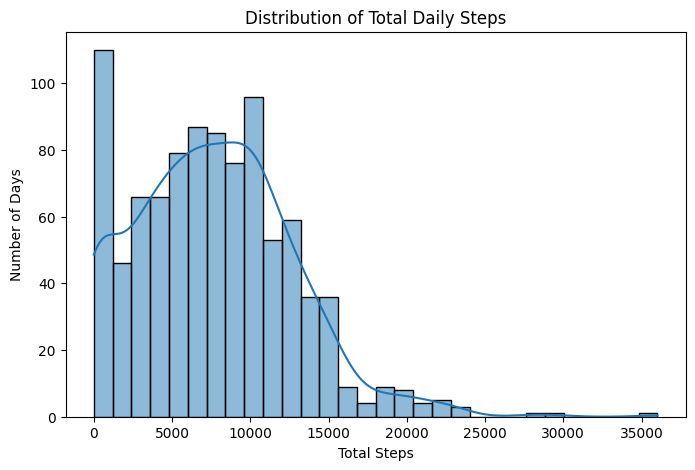

count      940.000000
mean      7637.910638
std       5087.150742
min          0.000000
25%       3789.750000
50%       7405.500000
75%      10727.000000
max      36019.000000
Name: TotalSteps, dtype: float64


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
daily = pd.read_csv('daily_clean.csv')
daily['Date'] = pd.to_datetime(daily['Date'])

# Distribution of TotalSteps
plt.figure(figsize=(8, 5))
sns.histplot(daily['TotalSteps'], bins=30, kde=True)
plt.title('Distribution of Total Daily Steps')
plt.xlabel('Total Steps')
plt.ylabel('Number of Days')
plt.show()

# The actual numbers behind the chart
print(daily['TotalSteps'].describe())

Daily step counts are right-skewed (mean 7,638 vs. median 7,406), with a cluster of zero-step days corresponding to non-wear days identified earlier. Only ~25% of days reach the commonly cited 10,000-step benchmark (75th percentile = 10,727), suggesting most users fall short of that target on a typical day.

**Chart 2: Calories distribution**

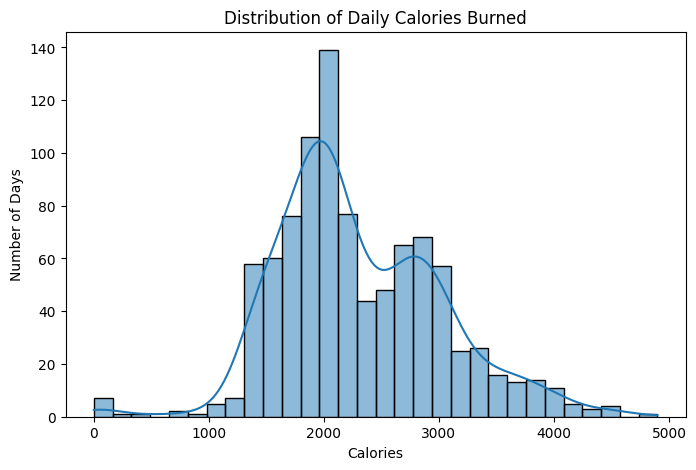

count     940.000000
mean     2303.609574
std       718.166862
min         0.000000
25%      1828.500000
50%      2134.000000
75%      2793.250000
max      4900.000000
Name: Calories, dtype: float64


In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(daily['Calories'], bins=30, kde=True)
plt.title('Distribution of Daily Calories Burned')
plt.xlabel('Calories')
plt.ylabel('Number of Days')
plt.show()

print(daily['Calories'].describe())

Daily calories burned is right-skewed (mean 2,304 vs. median 2,134) and shows two distinct peaks — a dominant cluster around 2,000 calories and a smaller secondary cluster around 2,700–2,900. This bimodal shape suggests the dataset mixes two different activity profiles rather than one uniform user behavior pattern, worth investigating further when segmenting users by activity level.

**Chart 3: Active minutes breakdown**

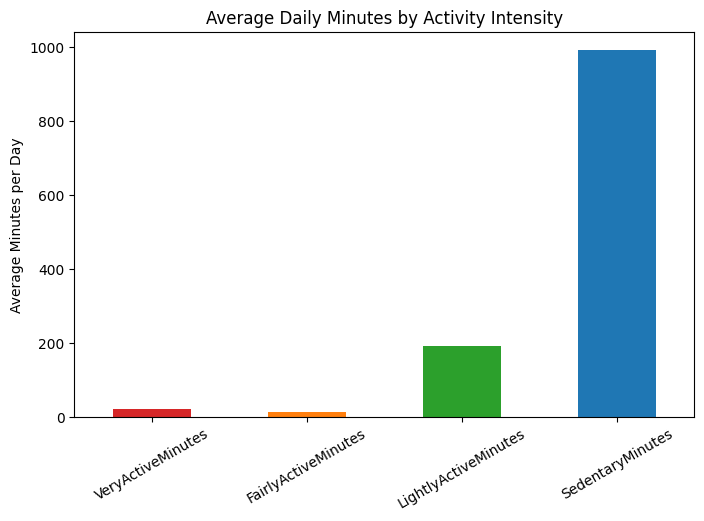

VeryActiveMinutes        21.164894
FairlyActiveMinutes      13.564894
LightlyActiveMinutes    192.812766
SedentaryMinutes        991.210638
dtype: float64


In [35]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']

plt.figure(figsize=(8, 5))
daily[activity_cols].mean().plot(kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
plt.title('Average Daily Minutes by Activity Intensity')
plt.ylabel('Average Minutes per Day')
plt.xticks(rotation=30)
plt.show()

print(daily[activity_cols].mean())

On average, users spend 991 minutes (~16.5 hours) sedentary per day, compared to just 21 minutes of very active and 14 minutes of fairly active time combined — sedentary time makes up roughly 81% of the tracked day, while high-intensity activity accounts for under 3%. This suggests the biggest opportunity for a fitness app isn't pushing harder workouts, but reducing sedentary stretches, since that's where the overwhelming majority of time already sits.

**Chart 4: Outlier check — boxplots for TotalSteps and Calories**

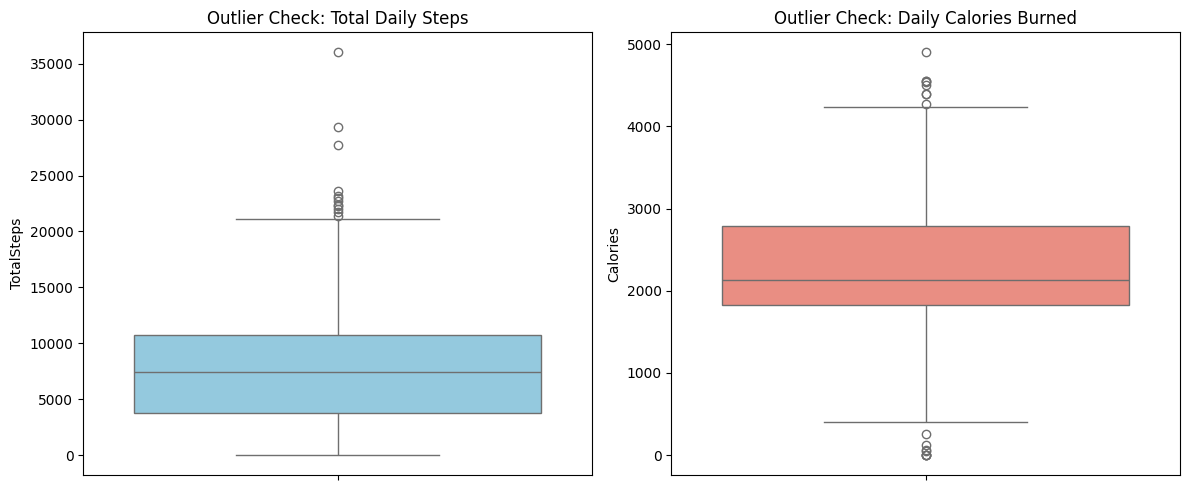

TotalSteps: 12 outliers (outside -6616 to 21133)
Calories: 16 outliers (outside 381 to 4240)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=daily['TotalSteps'], ax=axes[0], color='skyblue')
axes[0].set_title('Outlier Check: Total Daily Steps')

sns.boxplot(y=daily['Calories'], ax=axes[1], color='salmon')
axes[1].set_title('Outlier Check: Daily Calories Burned')

plt.tight_layout()
plt.show()

# Calculate outlier boundaries using the IQR method
for col in ['TotalSteps', 'Calories']:
    Q1 = daily[col].quantile(0.25)
    Q3 = daily[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = daily[(daily[col] < lower) | (daily[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (outside {lower:.0f} to {upper:.0f})")

Using the IQR method, 12 days are statistical outliers for steps (all above 21,133 — no low-end outliers, since step counts can't go negative), and 16 days are outliers for calories, split between a low end (near 0, consistent with the flagged non-wear days) and a high end (above 4,240, representing unusually intense activity days). These outliers aren't data errors — they reflect either non-wear days or genuinely high-activity days, so they're kept in the dataset rather than removed, consistent with the zero-activity handling decision made during cleaning.

**Chart 5: Steps vs. Calories correlation**

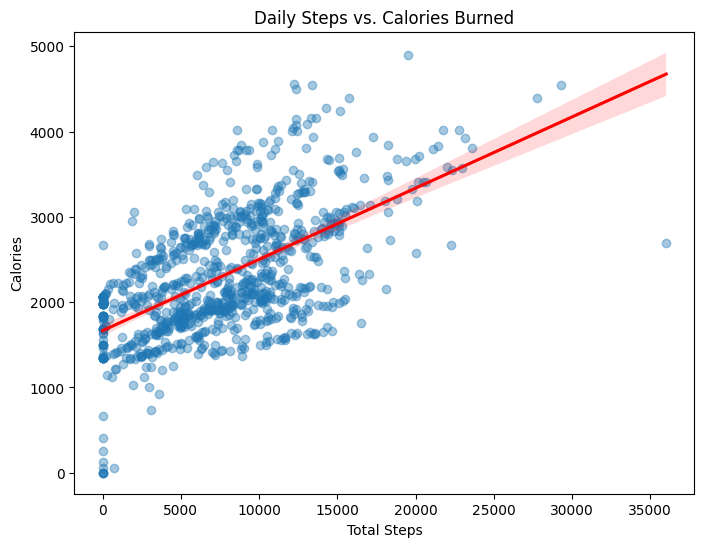

Correlation coefficient: 0.592


In [37]:
plt.figure(figsize=(8, 6))
sns.regplot(x='TotalSteps', y='Calories', data=daily, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Daily Steps vs. Calories Burned')
plt.xlabel('Total Steps')
plt.ylabel('Calories')
plt.show()

correlation = daily['TotalSteps'].corr(daily['Calories'])
print(f"Correlation coefficient: {correlation:.3f}")

Total steps and calories burned show a moderate positive correlation (r = 0.592) — more steps generally means more calories burned, but the relationship isn't tight, since other factors like resting metabolic rate and higher-intensity active minutes also contribute. Notably, the zero-step days still show a wide range of calories (0–2,100), reflecting baseline calorie burn independent of step count, and the single highest-step day (~36,000 steps) breaks from the trend, burning far fewer calories than the line would predict.

### Sleep — Distributions

In [38]:
# Load the cleaned sleep data
sleep = pd.read_csv('sleep_clean.csv')
sleep['Date'] = pd.to_datetime(sleep['Date'])

**Chart 6: Distribution of Total Minutes Asleep**

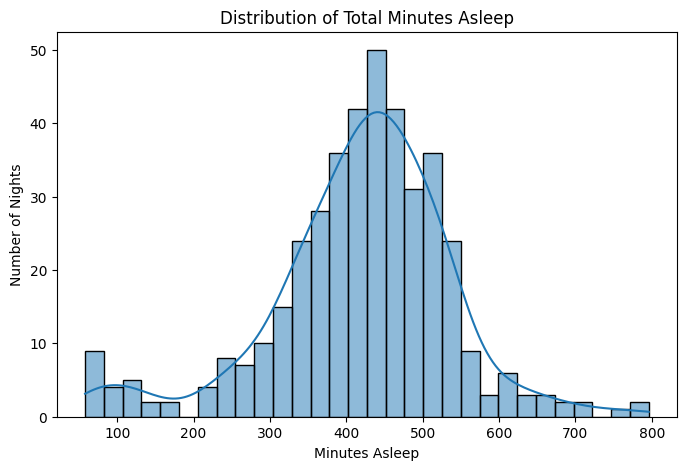

count    410.000000
mean     419.173171
std      118.635918
min       58.000000
25%      361.000000
50%      432.500000
75%      490.000000
max      796.000000
Name: TotalMinutesAsleep, dtype: float64


In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(sleep['TotalMinutesAsleep'], bins=30, kde=True)
plt.title('Distribution of Total Minutes Asleep')
plt.xlabel('Minutes Asleep')
plt.ylabel('Number of Nights')
plt.show()

print(sleep['TotalMinutesAsleep'].describe())

Total minutes asleep is roughly symmetric (mean 419 minutes / ~7.0 hours, median 432.5 minutes / ~7.2 hours), unlike the right-skewed activity and calorie distributions seen earlier. The bulk of nights fall between 400–500 minutes, aligning with commonly recommended 7–9 hour sleep guidelines. A smaller cluster of unusually short records (50–150 minutes) likely represents naps or partial tracking sessions rather than full nights of sleep, and should be treated separately from full-night sleep patterns in later analysis.

**Chart 7: Time in Bed vs. Minutes Asleep (Sleep Efficiency)**

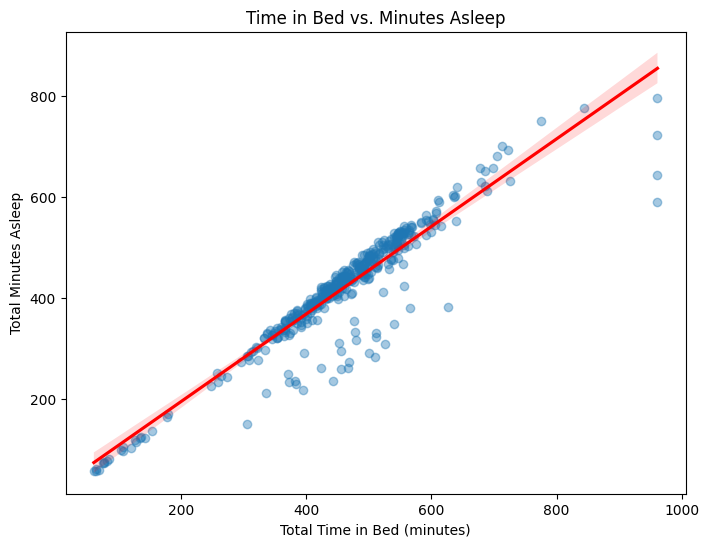

Correlation coefficient: 0.930
count    410.000000
mean      91.646671
std        8.728386
min       49.836066
25%       91.181156
50%       94.263857
75%       96.064164
max      100.000000
Name: sleep_efficiency, dtype: float64


In [40]:
plt.figure(figsize=(8, 6))
sns.regplot(x='TotalTimeInBed', y='TotalMinutesAsleep', data=sleep,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Time in Bed vs. Minutes Asleep')
plt.xlabel('Total Time in Bed (minutes)')
plt.ylabel('Total Minutes Asleep')
plt.show()

correlation = sleep['TotalTimeInBed'].corr(sleep['TotalMinutesAsleep'])
print(f"Correlation coefficient: {correlation:.3f}")

# Sleep efficiency = time actually asleep / time in bed, as a percentage
sleep['sleep_efficiency'] = (sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed']) * 100
print(sleep['sleep_efficiency'].describe())

Time in bed and minutes asleep are very strongly correlated (r = 0.930), as expected. More revealing is sleep efficiency (minutes asleep ÷ time in bed): the average night sits at 91.6% efficiency (median 94.3%), indicating most tracked nights involve minimal time lying awake. However, efficiency ranges as low as 49.8% on at least one night, showing that while most sleep is efficient, some nights involve substantial time awake in bed — a pattern a fitness app could flag for users as a signal worth addressing.

**Chart 8: Outlier Check — Total Minutes Asleep**

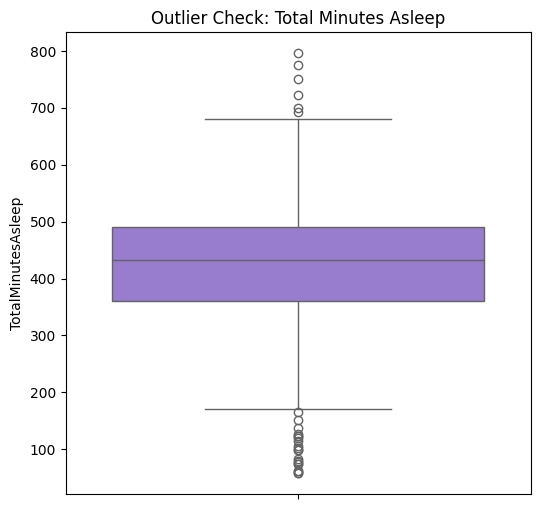

TotalMinutesAsleep: 27 outliers (outside 168 to 684)


In [41]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=sleep['TotalMinutesAsleep'], color='mediumpurple')
plt.title('Outlier Check: Total Minutes Asleep')
plt.show()

Q1 = sleep['TotalMinutesAsleep'].quantile(0.25)
Q3 = sleep['TotalMinutesAsleep'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = sleep[(sleep['TotalMinutesAsleep'] < lower) | (sleep['TotalMinutesAsleep'] > upper)]
print(f"TotalMinutesAsleep: {len(outliers)} outliers (outside {lower:.0f} to {upper:.0f})")

The IQR method flags 27 nights as outliers (outside 168–684 minutes), split between a low-end cluster (roughly 50–170 minutes) and a smaller high-end cluster (above 684 minutes, up to 796). The low-end cluster matches the short-sleep records already noted in the distribution chart, reinforcing that these are likely naps or partial tracking sessions rather than errors. As with the activity outliers, these are kept in the dataset rather than removed, since they represent real recorded behavior.

### Weight — Distributions

In [42]:
# Load the cleaned weight data
weight = pd.read_csv('weight_clean.csv')
weight['Date'] = pd.to_datetime(weight['Date'])

print(f"Unique users in weight data: {weight['Id'].nunique()}")

Unique users in weight data: 8


**Chart 9: Distribution of BMI**

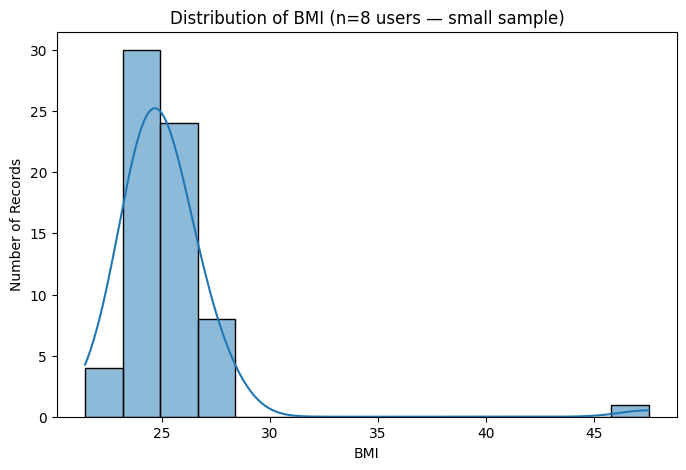

count    67.000000
mean     25.185224
std       3.066963
min      21.450001
25%      23.959999
50%      24.389999
75%      25.559999
max      47.540001
Name: BMI, dtype: float64


In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(weight['BMI'], bins=15, kde=True)
plt.title('Distribution of BMI (n=8 users — small sample)')
plt.xlabel('BMI')
plt.ylabel('Number of Records')
plt.show()

print(weight['BMI'].describe())

BMI data comes from only 8 unique users across 67 logged records, so this distribution reflects repeated entries from a small group, not a broad population. Most records cluster between BMI 21–28 (spanning WHO's "normal" to "overweight" bands), with a mean of 25.19 and median of 24.39. One outlier near BMI 47.5 — falling in the "obese" range — likely represents a single individual and visibly pulls the mean upward, illustrating how easily small-sample averages can be skewed by one person's data.

**Chart 10: Distribution of Weight (kg)**

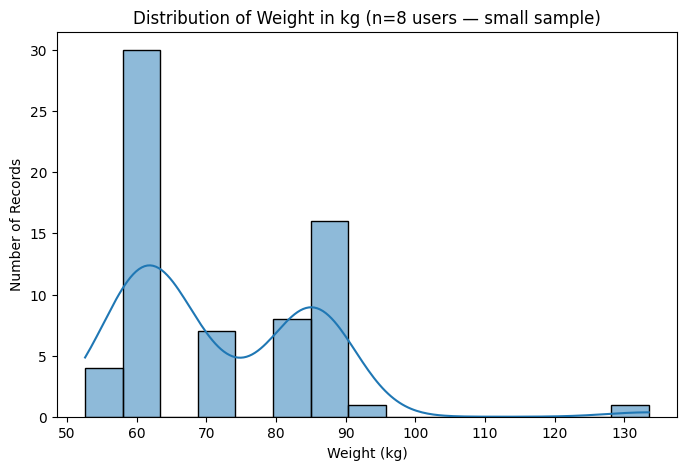

count     67.000000
mean      72.035821
std       13.923206
min       52.599998
25%       61.400002
50%       62.500000
75%       85.049999
max      133.500000
Name: WeightKg, dtype: float64

Per-user average weight:
Id
1503960366     52.599998
1927972279    133.500000
2873212765     57.000000
4319703577     72.350002
4558609924     69.639999
5577150313     90.699997
6962181067     61.553334
8877689391     85.145834
Name: WeightKg, dtype: float64


In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(weight['WeightKg'], bins=15, kde=True)
plt.title('Distribution of Weight in kg (n=8 users — small sample)')
plt.xlabel('Weight (kg)')
plt.ylabel('Number of Records')
plt.show()

print(weight['WeightKg'].describe())

# See per-user average, since n=8 users matters more here than raw record counts
print("\nPer-user average weight:")
print(weight.groupby('Id')['WeightKg'].mean())

This chart shows 67 records from only 8 users, so the visible clusters correspond to individual users' repeated log entries rather than a smooth population distribution. Per-user averages range from 52.6 kg to 133.5 kg. User 1927972279 averages 133.5 kg — far above the next-highest user at 90.7 kg — and is almost certainly the same individual behind the BMI ~47.5 outlier seen in the previous chart. Excluding this one user, the remaining 7 span a much tighter 52.6–90.7 kg range. With a sample this small, conclusions about "typical" weight should be treated as descriptive of these 8 specific people, not generalizable.

**Chart 11: Outlier Check — BMI (n=8 users — small sample)**

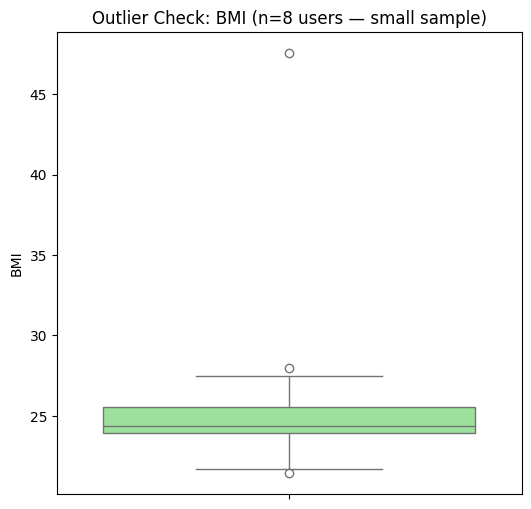

BMI: 3 outliers (outside 21.6 to 28.0)
            Id       Date        BMI
2   1927972279 2016-04-13  47.540001
3   2873212765 2016-04-21  21.450001
12  5577150313 2016-04-17  28.000000


In [45]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=weight['BMI'], color='lightgreen')
plt.title('Outlier Check: BMI (n=8 users — small sample)')
plt.show()

Q1 = weight['BMI'].quantile(0.25)
Q3 = weight['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = weight[(weight['BMI'] < lower) | (weight['BMI'] > upper)]
print(f"BMI: {len(outliers)} outliers (outside {lower:.1f} to {upper:.1f})")
print(outliers[['Id', 'Date', 'BMI']])

The IQR method flags 3 of 8 users as BMI outliers (outside 21.6–28.0): user 1927972279 at BMI 47.5 (confirming the individual identified in the weight distribution), user 2873212765 at BMI 21.45 (a low-end outlier), and user 5577150313 at BMI 28.0 (right at the upper boundary). With nearly 40% of this tiny sample flagging as outliers, this illustrates a key limitation of small-sample analysis: outlier detection becomes far less meaningful when there are only 8 data points to begin with, and no conclusion here should be generalized beyond these specific 8 individuals.

### Cross-Dataset Correlations

**Chart 12: Active Minutes vs. Sleep Duration**

Merged rows: 410 (out of 940 daily rows and 410 sleep rows)


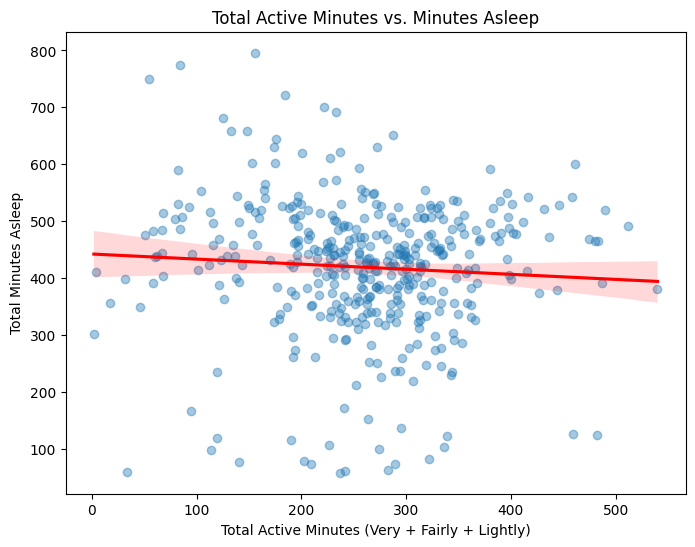

Correlation coefficient: -0.069


In [46]:
# Temporary merge — daily + sleep, just for this chart
activity_sleep = pd.merge(daily, sleep, on=['Id', 'Date'], how='inner')
print(f"Merged rows: {len(activity_sleep)} (out of {len(daily)} daily rows and {len(sleep)} sleep rows)")

# Total active minutes = Very + Fairly + Lightly Active
activity_sleep['TotalActiveMinutes'] = (
    activity_sleep['VeryActiveMinutes'] +
    activity_sleep['FairlyActiveMinutes'] +
    activity_sleep['LightlyActiveMinutes']
)

plt.figure(figsize=(8, 6))
sns.regplot(x='TotalActiveMinutes', y='TotalMinutesAsleep', data=activity_sleep,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Total Active Minutes vs. Minutes Asleep')
plt.xlabel('Total Active Minutes (Very + Fairly + Lightly)')
plt.ylabel('Total Minutes Asleep')
plt.show()

correlation = activity_sleep['TotalActiveMinutes'].corr(activity_sleep['TotalMinutesAsleep'])
print(f"Correlation coefficient: {correlation:.3f}")

Merging daily activity with sleep data (410 matched days) shows essentially no linear relationship between total active minutes and minutes asleep (r = -0.069). This challenges the common assumption that higher daytime activity directly predicts longer sleep — within this dataset, the two appear to operate largely independently. A fitness app shouldn't market "more activity leads to more sleep" as a guaranteed outcome based on this data; the actual drivers of sleep duration likely lie outside what's captured in activity minutes alone.

**Chart 13: BMI vs. Activity Level (per user)**

Users in this comparison: 8
           Id     AvgBMI  AvgTotalSteps
0  1503960366  22.650000   12116.741935
1  1927972279  47.540001     916.129032
2  2873212765  21.570001    7555.774194
3  4319703577  27.415000    7268.838710
4  4558609924  27.214000    7685.129032
5  5577150313  28.000000    8304.433333
6  6962181067  24.028000    9794.806452
7  8877689391  25.487083   16040.032258


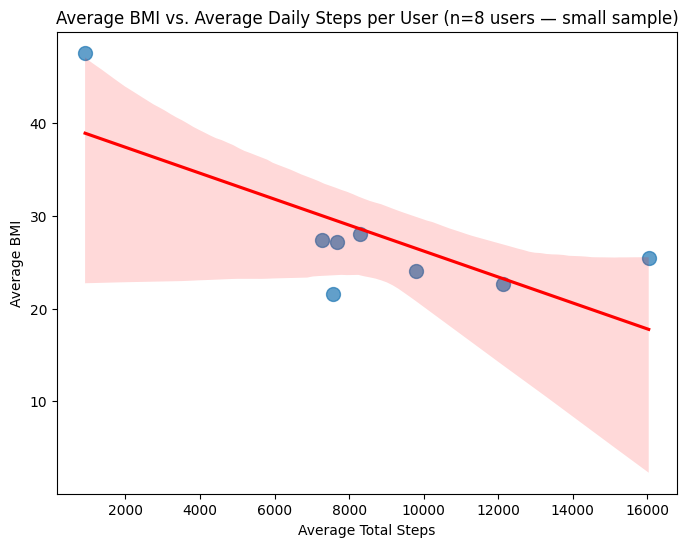

Correlation coefficient: -0.736


In [47]:
# Per-user average steps (activity level) from daily
avg_steps_per_user = daily.groupby('Id')['TotalSteps'].mean().reset_index()
avg_steps_per_user.columns = ['Id', 'AvgTotalSteps']

# Per-user average BMI from weight
avg_bmi_per_user = weight.groupby('Id')['BMI'].mean().reset_index()
avg_bmi_per_user.columns = ['Id', 'AvgBMI']

# Merge the two — only the 8 users who logged weight will have a match
bmi_activity = pd.merge(avg_bmi_per_user, avg_steps_per_user, on='Id', how='inner')
print(f"Users in this comparison: {len(bmi_activity)}")
print(bmi_activity)

plt.figure(figsize=(8, 6))
sns.regplot(x='AvgTotalSteps', y='AvgBMI', data=bmi_activity,
            scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':'red'})
plt.title('Average BMI vs. Average Daily Steps per User (n=8 users — small sample)')
plt.xlabel('Average Total Steps')
plt.ylabel('Average BMI')
plt.show()

correlation = bmi_activity['AvgTotalSteps'].corr(bmi_activity['AvgBMI'])
print(f"Correlation coefficient: {correlation:.3f}")

Across all 8 users, average steps and average BMI show a strong negative correlation (r = -0.736), suggesting more active users tend to have lower BMI. However, this is heavily influenced by a single user (1927972279) who has both extremely low average steps (916/day) and the highest BMI (47.5) in the sample — the same individual flagged as an outlier in Charts 9–11. Excluding just this one user, the correlation among the remaining 7 drops to r = -0.206, a weak relationship. This demonstrates how a single data point can dominate a correlation calculation when n is this small — the "strong" relationship shown here should not be presented as reliable evidence of a steps-BMI link without this caveat.

In [48]:
# Step 4: Merge all 3 cleaned datasets into one master table
# Base = daily (most complete), left join sleep and weight onto it

master = daily.merge(sleep, on=['Id', 'Date'], how='left')
master = master.merge(weight, on=['Id', 'Date'], how='left')

print(f"Master table shape: {master.shape}")
print(f"Rows: {len(master)} (should match daily's {len(daily)} rows)")
print(f"\nColumns: {list(master.columns)}")
print(f"\nNon-null counts per column:")
print(master.notna().sum())

Master table shape: (940, 25)
Rows: 940 (should match daily's 940 rows)

Columns: ['Id', 'Date', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'is_zero_activity', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed', 'sleep_efficiency', 'WeightKg', 'WeightPounds', 'BMI', 'IsManualReport', 'LogId']

Non-null counts per column:
Id                          940
Date                        940
TotalSteps                  940
TotalDistance               940
TrackerDistance             940
LoggedActivitiesDistance    940
VeryActiveDistance          940
ModeratelyActiveDistance    940
LightActiveDistance         940
SedentaryActiveDistance     940
VeryActiveMinutes           940
FairlyActiveMinutes         940
LightlyActiveMinutes        940
SedentaryMinutes 

### Master Table — Coverage Notes

The master table uses daily activity (940 rows, 33 users) as its base, with sleep and weight data attached where available via left join. This means:
- Activity columns: 100% populated (940/940 rows)
- Sleep columns: 44% populated (410/940 rows) — blank on days without a sleep log
- Weight columns: 7% populated (67/940 rows) — blank on days without a weight log

Blanks are expected and intentional, not missing/broken data — they reflect real gaps in what users chose to log.

In [49]:
master.to_csv('master_clean.csv', index=False)
print("Saved master_clean.csv")
print(f"Final shape: {master.shape}")

Saved master_clean.csv
Final shape: (940, 25)


## Cardiovascular Angle (Heart Rate)

In [50]:
# Load the raw heart rate file and inspect its structure before aggregating
hr_raw = pd.read_csv('heartrate_seconds_merged.csv')

print(f"Shape: {hr_raw.shape}")
print(f"Unique users: {hr_raw['Id'].nunique()}")
print(f"\nColumns: {list(hr_raw.columns)}")
print(f"\nFirst few rows:")
print(hr_raw.head())
print(f"\nDtypes:\n{hr_raw.dtypes}")

Shape: (2483658, 3)
Unique users: 14

Columns: ['Id', 'Time', 'Value']

First few rows:
           Id                  Time  Value
0  2022484408  4/12/2016 7:21:00 AM     97
1  2022484408  4/12/2016 7:21:05 AM    102
2  2022484408  4/12/2016 7:21:10 AM    105
3  2022484408  4/12/2016 7:21:20 AM    103
4  2022484408  4/12/2016 7:21:25 AM    101

Dtypes:
Id        int64
Time     object
Value     int64
dtype: object


In [51]:
# Convert Time to datetime, extract just the date
hr_raw['Time'] = pd.to_datetime(hr_raw['Time'], format='%m/%d/%Y %I:%M:%S %p')
hr_raw['Date'] = hr_raw['Time'].dt.date
hr_raw['Date'] = pd.to_datetime(hr_raw['Date'])

# Aggregate: one average heart rate value per user per day
heart_rate_daily = hr_raw.groupby(['Id', 'Date'])['Value'].mean().reset_index()
heart_rate_daily = heart_rate_daily.rename(columns={'Value': 'AvgDailyHeartRate'})

print(f"Aggregated shape: {heart_rate_daily.shape}")
print(f"Unique users: {heart_rate_daily['Id'].nunique()}")
print(heart_rate_daily.head())
print(f"\nAvgDailyHeartRate stats:\n{heart_rate_daily['AvgDailyHeartRate'].describe()}")

Aggregated shape: (334, 3)
Unique users: 14
           Id       Date  AvgDailyHeartRate
0  2022484408 2016-04-12          75.804177
1  2022484408 2016-04-13          80.337584
2  2022484408 2016-04-14          72.628597
3  2022484408 2016-04-15          80.437382
4  2022484408 2016-04-16          75.960547

AvgDailyHeartRate stats:
count    334.000000
mean      78.614059
std       10.613254
min       59.377175
25%       70.465679
50%       77.494179
75%       84.933171
max      109.789625
Name: AvgDailyHeartRate, dtype: float64


Merged rows: 334 (out of 334 heart rate day-records)
Unique users in merged data: 14


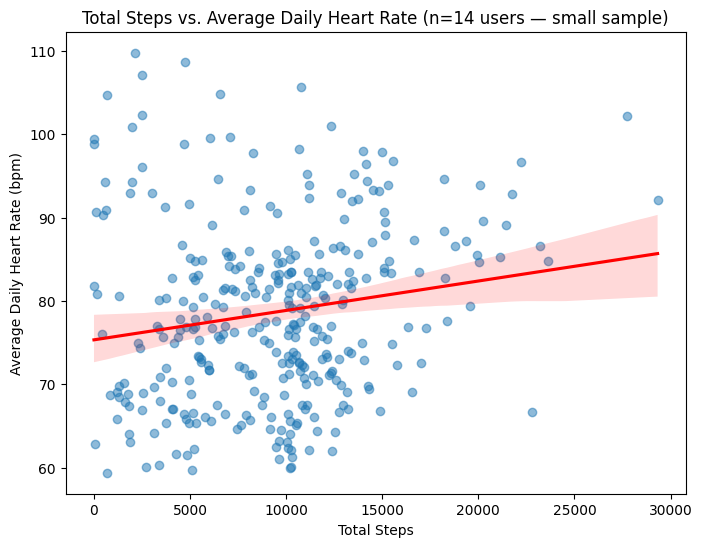

Correlation coefficient: 0.169


In [52]:
# Merge heart rate with daily activity, matching on Id + Date
hr_activity = pd.merge(heart_rate_daily, daily, on=['Id', 'Date'], how='inner')
print(f"Merged rows: {len(hr_activity)} (out of {len(heart_rate_daily)} heart rate day-records)")
print(f"Unique users in merged data: {hr_activity['Id'].nunique()}")

plt.figure(figsize=(8, 6))
sns.regplot(x='TotalSteps', y='AvgDailyHeartRate', data=hr_activity,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Total Steps vs. Average Daily Heart Rate (n=14 users — small sample)')
plt.xlabel('Total Steps')
plt.ylabel('Average Daily Heart Rate (bpm)')
plt.show()

correlation = hr_activity['TotalSteps'].corr(hr_activity['AvgDailyHeartRate'])
print(f"Correlation coefficient: {correlation:.3f}")

**Insight:** Using an average of all heart rate readings across each day (not
clinical resting heart rate, which is typically measured only during sleep or
full rest), the correlation between total steps and average daily heart rate
is weak and positive (r = 0.169) — the opposite direction from the common
assumption that higher activity predicts lower resting heart rate.

This result is more likely a methodology artifact than a real physiological
finding: because this metric averages in heart-rate readings taken *during*
exercise, more active days naturally include more elevated readings, which
pulls that day's average upward. A more accurate test of the "activity → lower
resting heart rate" hypothesis would isolate readings from actual rest periods
(e.g. overnight, or the lowest percentile of each day's readings) rather than
averaging the full day — something not attempted here given this is a
stretch-goal analysis with a small sample.

**Sample size caveat:** this analysis covers only 14 of 33 users (42%), and
should not be generalized beyond this specific subset.

## Key Findings

1. **Sedentary time dominates the day.** Users average 991 minutes (16.5 hours)
   sedentary per day, compared to just 21 minutes of very active time and 14
   minutes of fairly active time combined — sedentary time makes up roughly
   81% of the tracked day, while high-intensity activity accounts for under 3%.

2. **Most users fall short of the 10,000-step benchmark.** Only about 25% of
   tracked days reach or exceed 10,000 steps (75th percentile = 10,727 steps),
   with a mean of 7,638 steps per day.

3. **Steps and calories are moderately, not strongly, correlated (r = 0.592).**
   More steps generally means more calories burned, but other factors — like
   resting metabolic rate and higher-intensity active minutes — also play a
   meaningful role.

4. **Activity level does not predict sleep duration (r = -0.069), but
   sedentary time does (r = -0.60).** It isn't how active someone is that
   relates to their sleep — it's specifically how much sedentary time they
   accumulate. This is a more precise and more actionable finding than the
   common "exercise more, sleep better" assumption.

5. **No meaningful weekday/weekend activity difference.** Average steps
   (7,669 weekday vs. 7,551 weekend) and calories (2,302 vs. 2,310) are
   nearly identical, suggesting activity habits are driven by routine rather
   than the work-week structure.

6. **Non-wear days still carry information.** The 77 flagged zero-activity
   days average 1,657 calories (baseline/resting burn), compared to 2,361
   calories on logged activity days — a 30% gap that justified keeping these
   rows in the cleaned dataset rather than deleting them.

7. **Weight and BMI findings are based on only 8 users** and should not be
   generalized. One user's data (BMI ~47.5) visibly skews aggregate weight
   statistics — a clear demonstration of why small-sample findings need
   explicit caveats rather than being presented at face value.

8. **No evidence that higher activity predicts lower heart rate — using this
   dataset's average daily heart rate metric.** Total steps and average daily
   heart rate show a weak positive correlation (r = 0.169) — the opposite
   direction from the common assumption. This is most likely a methodology
   artifact (the metric averages in exercise-period readings, not just rest),
   rather than a genuine physiological effect. This finding covers only 14 of
   33 users (42%) and used a stretch-goal, non-clinical heart rate metric —
   it should not be treated as a reliable test of the activity–resting-heart-
   rate relationship.

## Recommendations

Based on the findings above, a fitness app targeting this type of user base
should consider:

1. **Target sedentary time, not just workout minutes.** Since sedentary time
   makes up 81% of the day and very/fairly active time is under 3%, the
   biggest opportunity isn't pushing harder workouts — it's nudging users to
   break up long sedentary stretches (e.g. hourly "stand up" reminders),
   since that's where the overwhelming majority of time already sits.

2. **Reframe sleep messaging around sedentary reduction, not exercise
   intensity.** Given sedentary minutes (not active minutes) correlate with
   shorter sleep (r = -0.60), messaging like "move more during the day to
   sleep better" is more accurate — and more actionable — than "work out
   harder to sleep better."

3. **Don't rely on weekday/weekend-specific campaigns.** Since activity is
   nearly flat across the week, a fitness app doesn't need separate
   weekday-vs-weekend engagement strategies for this user base — a consistent,
   daily nudge strategy is better supported by the data than day-specific
   timing.

4. **Treat non-wear days as an engagement signal, not noise.** The 77
   non-wear days in this dataset represent real behavior (skipped tracking),
   not bad data. A fitness app could use a similar signal to detect
   disengagement early and trigger a re-engagement prompt, rather than
   discarding these days from analysis.

5. **Be explicit about small-sample limitations in any weight/BMI feature.**
   With only 8 of 33 users logging weight, any weight-based feature (BMI
   tracking, goal-setting) should be framed as opt-in and personal, not
   benchmarked against "other users" — the current data simply doesn't
   support population-level weight comparisons.

6. **Don't market "more activity lowers your resting heart rate" without
   better-isolated data.** This analysis found no support for that claim using
   a full-day average heart rate metric — a fitness app should either avoid
   this specific claim, or invest in properly isolating rest-period readings
   (e.g. overnight data) before making it, rather than assuming the common
   fitness-industry narrative holds for its own users.

## Limitations

- This analysis uses a public dataset from 2016 (33 users, one month of data)
  as a proxy for Strava-style behavior — findings describe patterns in this
  specific dataset, not a live or current Strava user base.
- Sleep findings apply to 24 of 33 users; weight and BMI findings apply to
  only 8 of 33 users, and should not be generalized further.
- Correlation does not imply causation — the sedentary/sleep relationship
  (r = -0.60), for example, is a statistical association, not a proven
  causal mechanism.